In [1445]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.interpolate import griddata
import pandas as pd
import glob
from sklearn.linear_model import LinearRegression

In [1446]:
calibration_factor=2.31937536650301e-13

In [1447]:
# Get data file names
filenames = glob.glob("validation/simulated/4x4/*/*/pdd.out")

df4x4 = pd.DataFrame()
for filename in filenames:
    df4x4 = df4x4.add(pd.read_csv(filename, sep=r",", usecols=[2,3,4,5],
    names=['iZ','total', 'total^2','entries'], skiprows=4, engine="python"), fill_value=0)
df4x4=df4x4/np.size(filenames)

# Get data file names
filenames = glob.glob("validation/simulated/10x10/*/*/pdd.out")

df10x10 = pd.DataFrame()
for filename in filenames:
    df10x10 = df10x10.add(pd.read_csv(filename, sep=r",", usecols=[2,3,4,5],
    names=['iZ','total', 'total^2','entries'], skiprows=4, engine="python"), fill_value=0)
df10x10=df10x10/np.size(filenames)

# Get data file names
filenames = glob.glob("validation/simulated/40x40/*/*/pdd.out")

df40x40 = pd.DataFrame()
for filename in filenames:
    df40x40 = df40x40.add(pd.read_csv(filename, sep=r",", usecols=[2,3,4,5],
    names=['iZ','total', 'total^2','entries'], skiprows=4, engine="python"), fill_value=0)
df40x40=df40x40/np.size(filenames)

In [1448]:
z_aux, eDep_aux = np.loadtxt('validation/experimental/4x4/pdd',delimiter="\t",usecols =(0, 1),unpack=True)
exp4x4 = interp1d(z_aux, eDep_aux,kind="slinear")
z4x4 = np.linspace(3, 330.0, 325)
z_aux, eDep_aux = np.loadtxt('validation/experimental/10x10/pdd',delimiter="\t",usecols =(0, 1),unpack=True)
exp10x10 = interp1d(z_aux, eDep_aux,kind="slinear")
z10x10 = np.linspace(3, 330.0, 325)
z_aux, eDep_aux = np.loadtxt('validation/experimental/40x40/pdd',delimiter="\t",usecols =(0, 1),unpack=True)
exp40x40 = interp1d(z_aux, eDep_aux,kind="slinear")
z40x40 = np.linspace(3, 330.0, 325)

In [1449]:
K0='6MV'
zMax=500 # cm
nBins=125
scale=zMax/nBins
df4x4['iZ']=zMax-(df4x4['iZ'])*scale-2
df10x10['iZ']=zMax-(df10x10['iZ'])*scale-2
df40x40['iZ']=zMax-(df40x40['iZ'])*scale-2

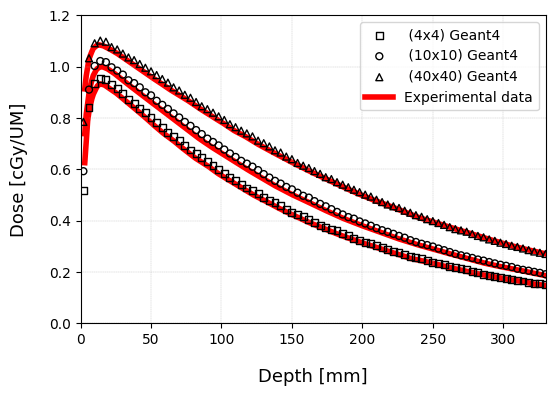

In [1450]:
fig=plt.figure(figsize=(6,4))

ax1=fig.add_subplot(111)
ax1.set_xlabel('Depth [mm]', fontsize=13,labelpad=15)
ax1.set_ylabel('Dose [cGy/UM]', fontsize=13,labelpad=15)
ax1.grid(linestyle='--', linewidth=0.25)
ax1.set_xlim(0,330)
ax1.set_ylim(0,1.2)
ax1.scatter(df4x4['iZ'], df4x4['total']*100*1.03, s=25, facecolors='none', edgecolors='black', label=" (4x4) Geant4",zorder=5,marker='s')
ax1.scatter(df10x10['iZ'], df10x10['total']*100*1.03, s=25, facecolors='none', edgecolors='black', label=" (10x10) Geant4",zorder=5)
ax1.scatter(df40x40['iZ'], df40x40['total']*100*1.03, s=25, facecolors='none', edgecolors='black', label=" (40x40) Geant4",zorder=5,marker='^')
ax1.plot(z4x4, exp4x4(z4x4), linestyle="-", linewidth=4, color="red", ms=5,zorder=1)
ax1.plot(z10x10, exp10x10(z10x10), linestyle="-", linewidth=4, color="red", ms=5,zorder=2,label="Experimental data")
ax1.plot(z40x40, exp40x40(z40x40), linestyle="-", linewidth=4, color="red", ms=5,zorder=1)


ax1.legend(loc='best')


In [1451]:
iZ=df10x10['iZ']
filter = (iZ >= np.min(z10x10)) & (iZ <= np.max(z10x10))

In [1452]:
iZ = iZ[filter]
diff4x4=((exp4x4(iZ))-(df4x4['total'][filter]*100*1.03))
diff10x10=((exp10x10(iZ))-(df10x10['total'][filter]*100*1.03))
diff40x40=((exp40x40(iZ))-(df40x40['total'][filter]*100*1.03))

In [1453]:
diffAll=np.append(diff4x4,diff10x10)
diffAll=np.append(diffAll,diff40x40)
iZAll=np.append(iZ,iZ)
iZAll=np.append(iZAll,iZ)

In [1454]:
reg = LinearRegression().fit(iZAll.reshape(-1, 1), diffAll)

# Optionally, check coefficients
print(f"Coefficients: {reg.coef_}")
print(f"Intercept: {reg.intercept_}")

Coefficients: [6.42713538e-05]
Intercept: -0.022704417462408373


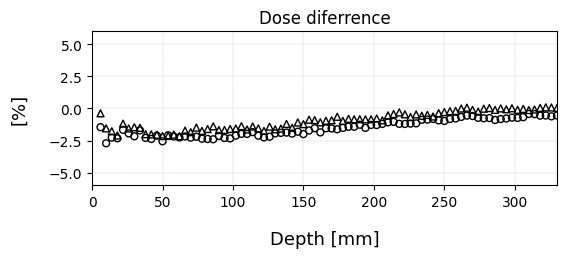

In [1455]:
fig=plt.figure(figsize=(6,2))

ax1=fig.add_subplot(111)
ax1.set_xlabel('Depth [mm]', fontsize=13,labelpad=15)
ax1.set_ylabel('[%]', fontsize=13,labelpad=15)
ax1.set_title('Dose diferrence')
ax1.grid(linestyle='--', linewidth=0.25)
ax1.set_xlim(0,330)
ax1.set_ylim(-6,6)
#ax1.scatter(iZ, diff4x4*100, s=25, facecolors='none', edgecolors='black', label=" (10x10) Geant4",zorder=4,marker='s')
ax1.scatter(iZ, diff10x10*100, s=25, facecolors='none', edgecolors='black', label=" (10x10) Geant4",zorder=4)
ax1.scatter(iZ, diff40x40*100, s=25, facecolors='none', edgecolors='black', label=" (40x40) Geant4",zorder=4,marker='^')
#plt.plot(iZAll.reshape(-1, 1), reg.predict(iZAll.reshape(-1, 1))*100, color='blue',linewidth=4)
#ax1.legend(loc='best')


(array([ 1.,  3., 17., 32., 37., 27., 30., 46., 32., 21.]),
 array([-3.14203069, -2.81925634, -2.49648198, -2.17370763, -1.85093327,
        -1.52815892, -1.20538456, -0.88261021, -0.55983585, -0.23706149,
         0.08571286]),
 <BarContainer object of 10 artists>)

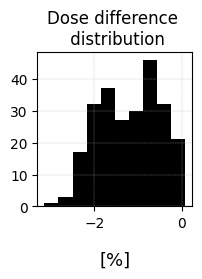

In [1456]:
fig=plt.figure(figsize=(2,2))

ax1=fig.add_subplot(111)
ax1.set_xlabel('[%]', fontsize=13,labelpad=15)
ax1.set_title('Dose difference \n distribution')
ax1.grid(linestyle='--', linewidth=0.25)
plt.hist(diffAll*100, color='black')



In [1457]:
print(np.mean(diffAll))
print(np.std(diffAll))

-0.01190683002599667
0.007007004388381302


In [1458]:
# Get data file names
filenames = glob.glob("validation/simulated/10x10/*/*/pddBuildup.out")

df10x10 = pd.DataFrame()
for filename in filenames:
    df10x10 = df10x10.add(pd.read_csv(filename, sep=r",", usecols=[2,3,4,5],
    names=['iZ','total', 'total^2','entries'], skiprows=4, engine="python"), fill_value=0)
df10x10=df10x10/np.size(filenames)

In [1459]:
K0='6MV'
zMax=24 # mm
nBins=12
scale=zMax/nBins
df10x10['iZ']=zMax-(df10x10['iZ'])*scale
df10x10['total']=df10x10['total']

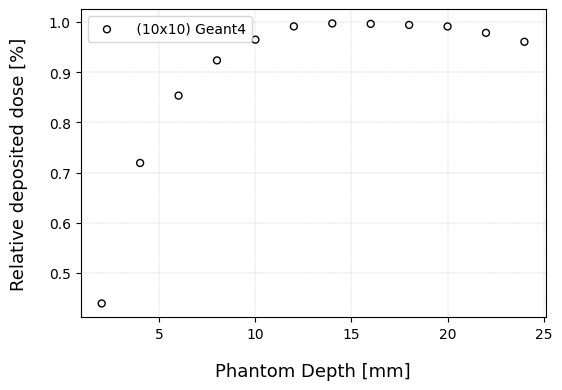

In [1460]:
fig=plt.figure(figsize=(6,4))
#fig.suptitle("title", fontsize=16)

ax1=fig.add_subplot(111)
ax1.set_xlabel('Phantom Depth [mm]', fontsize=13,labelpad=15)
ax1.set_ylabel('Relative deposited dose [%]', fontsize=13,labelpad=15)
ax1.grid(linestyle='--', linewidth=0.25)

ax1.scatter(df10x10['iZ'], df10x10['total']*100*1.005, s=25, facecolors='none', edgecolors='black', label=" (10x10) Geant4",zorder=4)


ax1.legend(loc='best')

In [1461]:
# Get data file names
filenames = glob.glob("validation/simulated/4x4/*/*/latProfile_x.out")

df4x4 = pd.DataFrame()
for filename in filenames:
    df4x4 = df4x4.add(pd.read_csv(filename, sep=r",", usecols=[0,3,4,5],
    names=['iX','total', 'total^2','entries'], skiprows=4, engine="python"), fill_value=0)
df4x4=df4x4/np.size(filenames)

# Get data file names
filenames = glob.glob("validation/simulated/10x10/*/*/latProfile_x.out")

df10x10 = pd.DataFrame()
for filename in filenames:
    df10x10 = df10x10.add(pd.read_csv(filename, sep=r",", usecols=[0,3,4,5],
    names=['iX','total', 'total^2','entries'], skiprows=4, engine="python"), fill_value=0)
df10x10=df10x10/np.size(filenames)

# Get data file names
filenames = glob.glob("validation/simulated/40x40/*/*/latProfile_x.out")

df40x40 = pd.DataFrame()
for filename in filenames:
    df40x40 = df40x40.add(pd.read_csv(filename, sep=r",", usecols=[0,3,4,5],
    names=['iX','total', 'total^2','entries'], skiprows=4, engine="python"), fill_value=0)
df40x40=df40x40/np.size(filenames)

In [1462]:
x_aux, eDep_aux = np.loadtxt('validation/experimental/4x4/latProfile_x',delimiter="\t",usecols =(0, 1),unpack=True)
expLat4x4 = interp1d(x_aux, eDep_aux,kind="slinear")
x4x4 = np.linspace(-50, 50.0, 50)
filter = (x_aux>0) & (eDep_aux >= 0.1) & (eDep_aux <= 0.9)
expLat4x4_inv = interp1d(eDep_aux[filter],x_aux[filter],kind="slinear")
x_aux, eDep_aux = np.loadtxt('validation/experimental/10x10/latProfile_x',delimiter="\t",usecols =(0, 1),unpack=True)
expLat10x10 = interp1d(x_aux, eDep_aux,kind="slinear")
x10x10 = np.linspace(-100, 100.0, 100)
filter = (x_aux>0) & (eDep_aux >= 0.1) & (eDep_aux <= 0.9)
expLat10x10_inv = interp1d(eDep_aux[filter],x_aux[filter],kind="slinear")
x_aux, eDep_aux = np.loadtxt('validation/experimental/40x40/latProfile_x',delimiter="\t",usecols =(0, 1),unpack=True)
expLat40x40 = interp1d(x_aux, eDep_aux,kind="slinear")
x40x40 = np.linspace(-250, 250.0, 250)
filter = (x_aux>0) & (eDep_aux >= 0.1) & (eDep_aux <= 0.9)
expLat40x40_inv = interp1d(eDep_aux[filter],x_aux[filter],kind="slinear")

In [1463]:
K0='6MV'
xMax=500 # cm
nBins=125
scale=xMax/nBins
df4x4['iX']=xMax-(df4x4['iX'])*scale-252
df10x10['iX']=xMax-(df10x10['iX'])*scale-252
df40x40['iX']=xMax-(df40x40['iX'])*scale-252

In [1464]:
sim4x4_latx = interp1d(df4x4['iX'],df4x4['total'],kind="slinear")
xSim4x4 = np.linspace(-248, 248.0, 248)

sim10x10_latx = interp1d(df10x10['iX'],df10x10['total'],kind="slinear")
xSim10x10 = np.linspace(-248, 248.0, 248)

sim40x40_latx = interp1d(df40x40['iX'],df40x40['total'],kind="slinear")
xSim40x40 = np.linspace(-248, 248.0, 248)

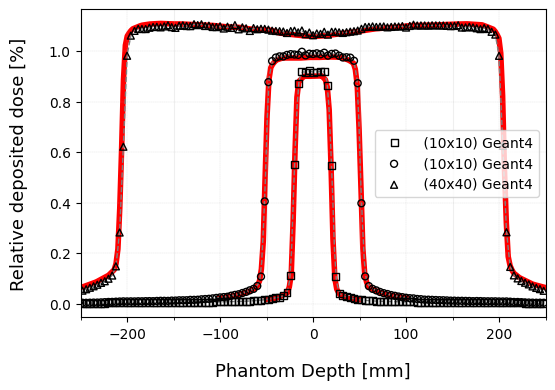

In [1465]:
fig=plt.figure(figsize=(6,4))
#fig.suptitle("title", fontsize=16)

ax1=fig.add_subplot(111)
ax1.set_xlabel('Phantom Depth [mm]', fontsize=13,labelpad=15)
ax1.set_ylabel('Relative deposited dose [%]', fontsize=13,labelpad=15)
# Major ticks every 20, minor ticks every 5
major_ticks = np.arange(-400, 400, 100)
minor_ticks = np.arange(-350, 350, 50)

ax1.set_xticks(major_ticks)
ax1.set_xticks(minor_ticks, minor=True)
ax1.grid(linestyle='--', linewidth=0.25)
# Or if you want different settings for the grids:
ax1.grid(which='minor', alpha=0.2)
ax1.grid(which='major', alpha=0.5)
#
ax1.set_xlim(-250,250)
#ax1.set_ylim(0,1.2)
ax1.scatter(df4x4['iX'], df4x4['total']*100*1.03, s=25, facecolors='none', edgecolors='black', label=" (10x10) Geant4",zorder=5, marker='s')
ax1.scatter(df10x10['iX'], df10x10['total']*100*1.03, s=25, facecolors='none', edgecolors='black', label=" (10x10) Geant4",zorder=5)
ax1.scatter(df40x40['iX'], df40x40['total']*100*1.03, s=25, facecolors='none', edgecolors='black', label=" (40x40) Geant4",zorder=5, marker='^')
ax1.plot(xSim4x4, sim4x4_latx(xSim4x4)*100*1.03, linestyle="--", linewidth=1, color="gray", ms=5,zorder=2)
ax1.plot(xSim10x10, sim10x10_latx(xSim10x10)*100*1.03, linestyle="--", linewidth=1, color="gray", ms=5,zorder=2)
ax1.plot(xSim40x40, sim40x40_latx(xSim40x40)*100*1.03, linestyle="--", linewidth=1, color="gray", ms=5,zorder=2)
ax1.plot(x4x4, expLat4x4(x4x4), linestyle="-", linewidth=4, color="red", ms=5,zorder=1)
ax1.plot(x10x10, expLat10x10(x10x10), linestyle="-", linewidth=4, color="red", ms=5,zorder=1)
ax1.plot(x40x40, expLat40x40(x40x40), linestyle="-", linewidth=4, color="red", ms=5,zorder=1)

ax1.legend(loc='best')

In [1466]:
iX4x4=df4x4['iX']
filter = (iX4x4 >= np.min(x4x4)) & (iX4x4 <= np.max(x4x4))
iX4x4 = iX4x4[filter]
diff4x4=((expLat4x4(iX4x4))-np.array(df4x4['total'][filter]*100*1.03))
iX10x10=df10x10['iX']
filter = (iX10x10 >= np.min(x10x10)) & (iX10x10 <= np.max(x10x10))
iX10x10 = iX10x10[filter]
diff10x10=(expLat10x10(iX10x10)-np.array(df10x10['total'][filter]*100*1.03))
iX40x40=df40x40['iX']
filter = (iX40x40 >= np.min(x40x40)) & (iX40x40 <= np.max(x40x40))
iX40x40 = iX40x40[filter]
diff40x40=(expLat40x40(iX40x40)-np.array(df40x40['total'][filter]*100*1.03))

In [1467]:
diffAll=np.append(diff4x4,diff10x10)
diffAll=np.append(diffAll,diff40x40)
iXAll=np.append(iX4x4[filter],iX10x10[filter])
iZAll=np.append(iZAll,iZ)

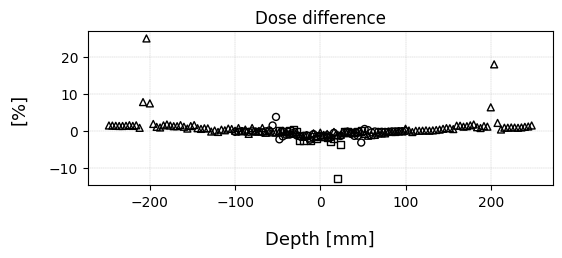

In [1468]:
fig=plt.figure(figsize=(6,2))

ax1=fig.add_subplot(111)
ax1.set_xlabel('Depth [mm]', fontsize=13,labelpad=15)
ax1.set_ylabel('[%]', fontsize=13,labelpad=15)
ax1.set_title('Dose difference')
ax1.grid(linestyle='--', linewidth=0.25)
#ax1.set_xlim(,330)
#ax1.set_ylim(-6,6)
ax1.scatter(iX4x4, diff4x4*100, s=25, facecolors='none', edgecolors='black', label=" (10x10) Geant4",zorder=4,marker='s')
ax1.scatter(iX10x10, diff10x10*100, s=25, facecolors='none', edgecolors='black', label=" (10x10) Geant4",zorder=4)
ax1.scatter(iX40x40, diff40x40*100, s=25, facecolors='none', edgecolors='black', label=" (40x40) Geant4",zorder=4,marker='^')
#ax1.legend(loc='best')


(array([  1.,   0.,  19., 175.,   1.,   3.,   0.,   0.,   1.,   1.]),
 array([-12.88798198,  -9.09966246,  -5.31134295,  -1.52302343,
          2.26529608,   6.0536156 ,   9.84193511,  13.63025462,
         17.41857414,  21.20689365,  24.99521317]),
 <BarContainer object of 10 artists>)

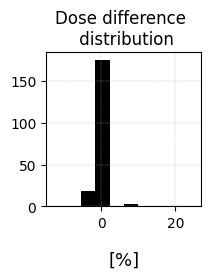

In [1469]:
fig=plt.figure(figsize=(2,2))

ax1=fig.add_subplot(111)
ax1.set_xlabel('[%]', fontsize=13,labelpad=15)
ax1.set_title('Dose difference \n distribution')
ax1.grid(linestyle='--', linewidth=0.25)
#ax1.set_xlim(0,330)
#ax1.set_xlim(-5,5)
plt.hist(diffAll*100, color='black')
#ax1.legend(loc='best')